# **KKBOX Churn Prediction And Retention Intelligence System - Initial Data & Business Understanding Exploration**

---

## **1. Objective**

This notebook explores our dataset to build an initial understanding of customer churn.

The goal is to:
- Understand the structure and quality of the data
- Identify potential issues and limitations
- Explore early patterns related to churn
- Generate initial business hypotheses

At this stage, the focus is exploratory. No modeling or heavy preprocessing is applied yet.


---

## **2. Setup**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


current_dir = os.getcwd()


while not os.path.exists(os.path.join(current_dir, "data", "raw")):
    parent = os.path.dirname(current_dir)
    if parent == current_dir:
        raise FileNotFoundError("Project root with data/raw not found")
    current_dir = parent


os.chdir(current_dir)

print("Project root:", os.getcwd())
print("data/raw exists:", os.path.exists("data/raw"))


pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

target = "is_churn"


---

## **3. Data Overview**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   msno      970960 non-null  object
 1   is_churn  970960 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 14.8+ MB

Missing values in train:
msno        0
is_churn    0
dtype: int64

Duplicates users in train:
Duplicated users: 0


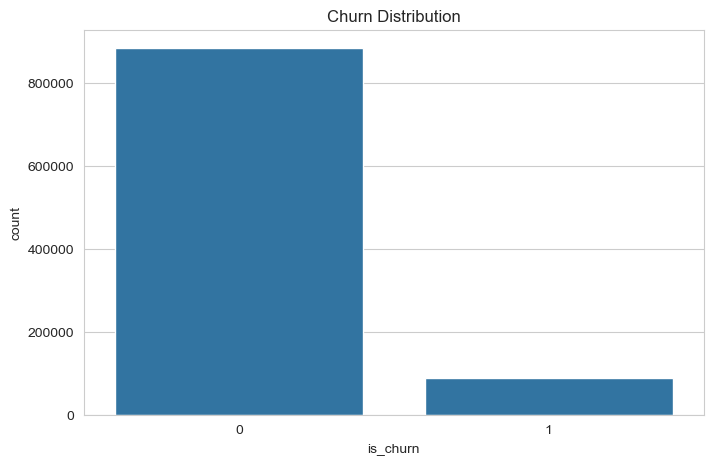

Churn rate: 8.99%


In [50]:
# 3.1 Train Dataset (Target)
train = pd.read_csv("data/raw/train_v2.csv")

train.info()
train.head()
print("\nMissing values in train:")
print(train.isnull().sum())
print("\nDuplicates users in train:")
print("Duplicated users:", train["msno"].duplicated().sum())
sns.countplot(x=target, data=train)
plt.title("Churn Distribution")
plt.show()

print(f"Churn rate: {train[target].mean()*100:.2f}%")


**Insight**
- The dataset is clean (no missing values, no duplicates)
- Churn rate is ~9%, indicating class imbalance
- This will be important for model evaluation later

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6769473 entries, 0 to 6769472
Data columns (total 6 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   msno                    object
 1   city                    int64 
 2   bd                      int64 
 3   gender                  object
 4   registered_via          int64 
 5   registration_init_time  int64 
dtypes: int64(4), object(2)
memory usage: 309.9+ MB

Missing values in members:
msno                      0.00
city                      0.00
bd                        0.00
gender                    0.65
registered_via            0.00
registration_init_time    0.00
dtype: float64

Duplicated customer IDs: 0
Duplicated rows: 0


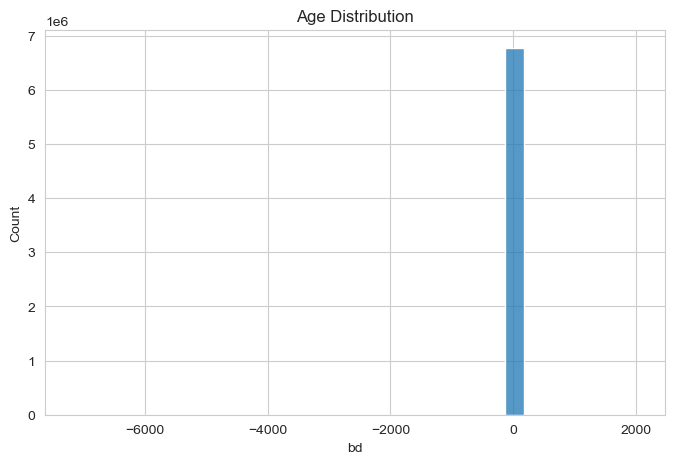

In [51]:
# 3.2 Members Dataset
members = pd.read_csv("data/raw/members_v3.csv")

members.info()
members.head()
print("\nMissing values in members:")
print(members.isnull().mean().round(2))
print("\nDuplicated customer IDs:", members["msno"].duplicated().sum())
print("Duplicated rows:", members.duplicated().sum())
sns.histplot(members["bd"], bins=30)
plt.title("Age Distribution")
plt.show()

**Insight**
- Age (`bd`) contains invalid values (0, negative, extreme)
- Gender has a high percentage of missing values (~65%)
- The dataset has no duplicates
- Some numerical variables behave like categorical (city, registered_via)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1431009 entries, 0 to 1431008
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   msno                    1431009 non-null  object
 1   payment_method_id       1431009 non-null  int64 
 2   payment_plan_days       1431009 non-null  int64 
 3   plan_list_price         1431009 non-null  int64 
 4   actual_amount_paid      1431009 non-null  int64 
 5   is_auto_renew           1431009 non-null  int64 
 6   transaction_date        1431009 non-null  int64 
 7   membership_expire_date  1431009 non-null  int64 
 8   is_cancel               1431009 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 98.3+ MB

Missing values in transactions:
msno                      0.0
payment_method_id         0.0
payment_plan_days         0.0
plan_list_price           0.0
actual_amount_paid        0.0
is_auto_renew             0.0
transaction_date          0.0


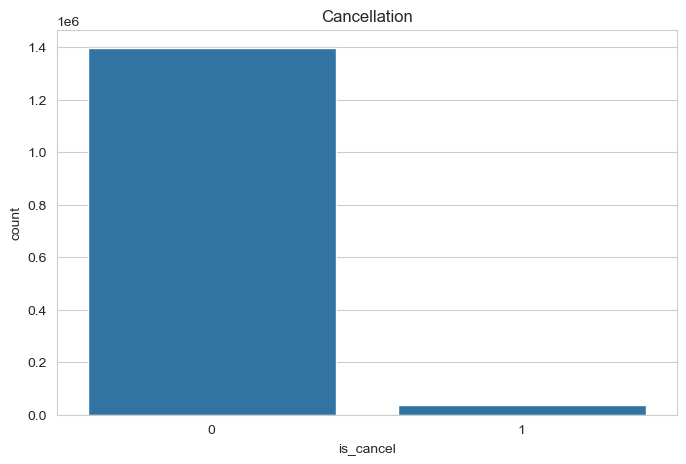

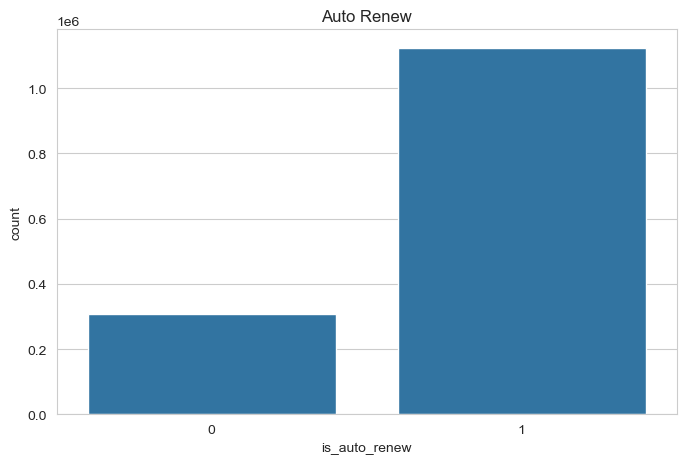

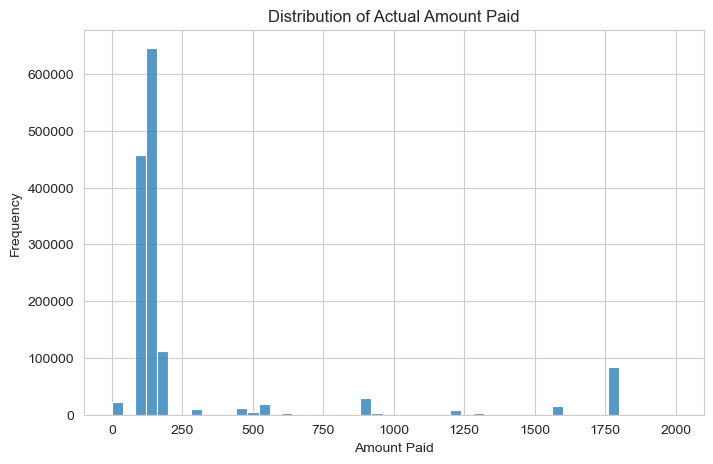

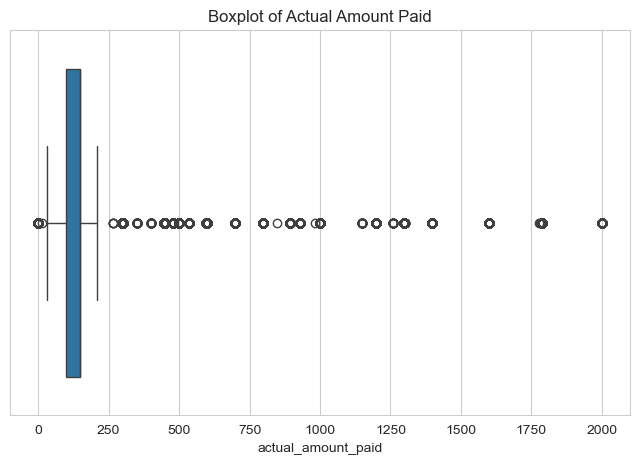

In [ ]:
# 3.3 Transactions Dataset
transactions = pd.read_csv("data/raw/transactions_v2.csv")

transactions.info()
transactions.head()

print("\nMissing values in transactions:")
print(transactions.isnull().mean().round(2))

sns.countplot(x="is_cancel", data=transactions)
plt.title("Cancellation")
plt.show()

sns.countplot(x="is_auto_renew", data=transactions)
plt.title("Auto Renew")
plt.show()


sns.histplot(transactions["actual_amount_paid"], bins=50)
plt.title("Distribution of Actual Amount Paid")
plt.xlabel("Amount Paid")
plt.ylabel("Frequency")
plt.show()


sns.boxplot(x=transactions["actual_amount_paid"])
plt.title("Boxplot of Actual Amount Paid")
plt.show()


**Insight**
- Multiple transactions per user
- Auto-renew and cancellation stand out as key behavioral signals
- Payment variables show high variability

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18396362 entries, 0 to 18396361
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   msno        object 
 1   date        int64  
 2   num_25      int64  
 3   num_50      int64  
 4   num_75      int64  
 5   num_985     int64  
 6   num_100     int64  
 7   num_unq     int64  
 8   total_secs  float64
dtypes: float64(1), int64(7), object(1)
memory usage: 1.2+ GB

Missing values in user logs:
msno          0.0
date          0.0
num_25        0.0
num_50        0.0
num_75        0.0
num_985       0.0
num_100       0.0
num_unq       0.0
total_secs    0.0
dtype: float64


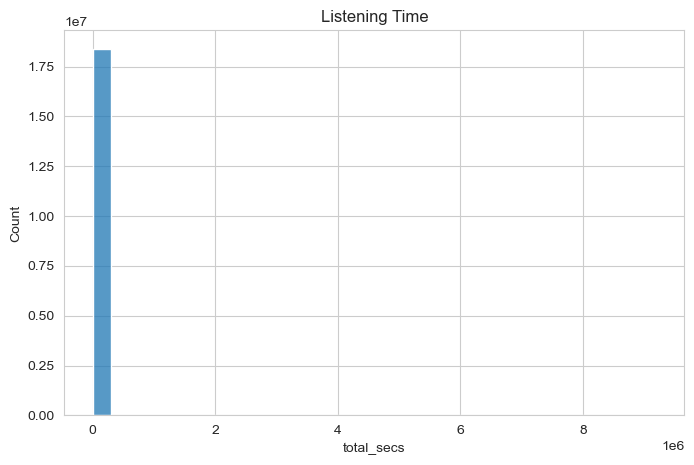

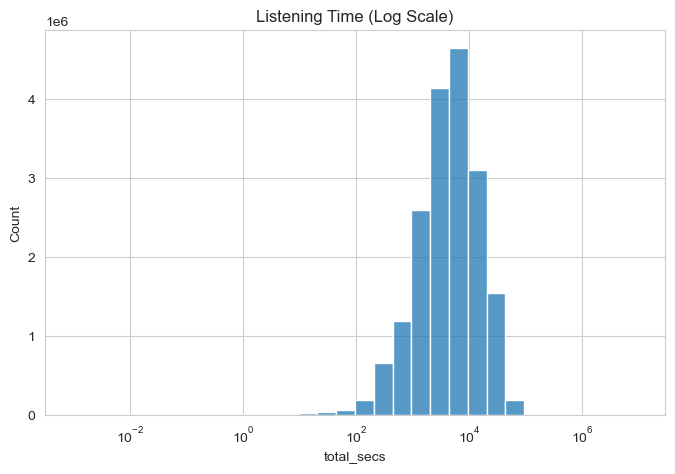

In [48]:
# 3.4 User Logs Dataset
user_logs = pd.read_csv("data/raw/user_logs_v2.csv")

user_logs.info()
print("\nMissing values in user logs:")
print(user_logs.isnull().mean().round(2))
sns.histplot(user_logs["total_secs"], bins=30)
plt.title("Listening Time")
plt.show()

sns.histplot(user_logs["total_secs"], bins=30, log_scale=True)
plt.title("Listening Time (Log Scale)")
plt.show()

 **Insight**
- Very large dataset (multiple rows per user)
- Engagement is highly skewed (few heavy users)

---

## **4. Quick Merge (Initial Exploration)**

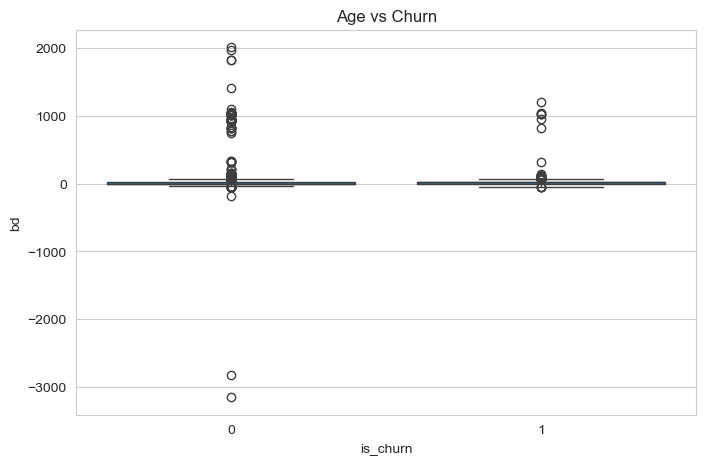

In [6]:
train_members = train.merge(members, on="msno", how="left")
sns.boxplot(x="is_churn", y="bd", data=train_members)
plt.title("Age vs Churn")
plt.show()

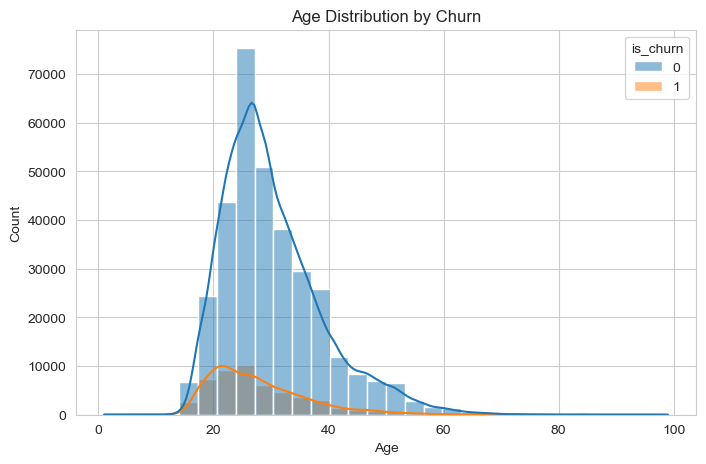

In [26]:
# --- Age vs Churn (Histogram)
# Filter unrealistic ages
age_filtered = train_members[(train_members["bd"] > 0) & (train_members["bd"] < 100)]

sns.histplot(data=age_filtered, x="bd", hue="is_churn", bins=30, kde=True)
plt.title("Age Distribution by Churn")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


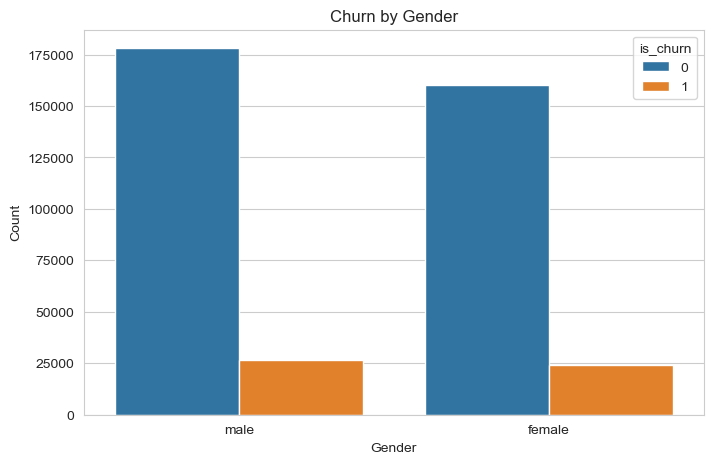

Churn Rate by Gender (%):
female: 12.99%
male: 12.90%


In [29]:
# --- Gender vs Churn (Histogram / Countplot)
sns.countplot(data=train_members, x="gender", hue="is_churn")
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

gender_churn_pct = (
train_members
.groupby("gender")["is_churn"]
.mean() * 100
)

print("Churn Rate by Gender (%):")
for gender, pct in gender_churn_pct.items():
  print(f"{gender}: {pct:.2f}%")


 **Insight**
- Demographics alone do not clearly explain churn
- Behavioral data will likely be more informative

---

## **5. Build Customer-Level Dataset**

In [7]:
# 5.1 Aggregate User Logs
user_logs = pd.read_csv("data/raw/user_logs_v2.csv")

user_logs_agg = user_logs.groupby("msno").agg({
    "total_secs": "sum",
    "num_unq": "sum"
}).reset_index()
print("\nAggregated user logs info:")
print(user_logs_agg.info())


Aggregated user logs info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103894 entries, 0 to 1103893
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   msno        1103894 non-null  object 
 1   total_secs  1103894 non-null  float64
 2   num_unq     1103894 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 25.3+ MB
None


In [8]:
# 5.2 Aggregate Transactions

# Convert date columns
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    errors="coerce"
)

transactions["membership_expire_date"] = pd.to_datetime(
    transactions["membership_expire_date"],
    errors="coerce"
)

# Aggregate transaction data at customer level
transactions_agg = transactions.groupby("msno").agg({
    "actual_amount_paid": ["sum", "mean"],
    "payment_plan_days": ["sum", "mean"],
    "plan_list_price": "mean",
    "is_auto_renew": ["mean", "max"],
    "is_cancel": ["mean", "max"],
    "transaction_date": ["count", "min", "max"],
    "membership_expire_date": "max"
}).reset_index()

transactions_agg.columns = [
    "msno",
    "total_amount_paid",
    "avg_amount_paid",
    "total_payment_plan_days",
    "avg_payment_plan_days",
    "avg_plan_list_price",
    "auto_renew_rate",
    "has_auto_renew",
    "cancel_rate",
    "has_cancelled",
    "transaction_count",
    "first_transaction_date",
    "last_transaction_date",
    "membership_expire_date"
]

transactions_agg.head()


print(transactions["transaction_date"].head())
print(transactions["transaction_date"].dtype)


0   1970-01-01 00:00:00.020170131
1   1970-01-01 00:00:00.020150809
2   1970-01-01 00:00:00.020170303
3   1970-01-01 00:00:00.020170329
4   1970-01-01 00:00:00.020170323
Name: transaction_date, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
# 5.3 Final Dataset

df = train.merge(members, on="msno", how="left")
df = df.merge(transactions_agg, on="msno", how="left")
df = df.merge(user_logs_agg, on="msno", how="left")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   msno                     970960 non-null  object        
 1   is_churn                 970960 non-null  int64         
 2   city                     860967 non-null  float64       
 3   bd                       860967 non-null  float64       
 4   gender                   388905 non-null  object        
 5   registered_via           860967 non-null  float64       
 6   registration_init_time   860967 non-null  float64       
 7   total_amount_paid        933578 non-null  float64       
 8   avg_amount_paid          933578 non-null  float64       
 9   total_payment_plan_days  933578 non-null  float64       
 10  avg_payment_plan_days    933578 non-null  float64       
 11  avg_plan_list_price      933578 non-null  float64       
 12  auto_renew_rate 

---

## **6. Key Business Questions**

In [11]:
# 6.1 Which segments churn more?
# Churn rate by auto-renew
auto_renew_churn = df.groupby("has_auto_renew")[target].mean() * 100

print("Churn Rate by Auto-Renew Status (%):")
for status, value in auto_renew_churn.items():
   print(f"Auto-Renew = {int(status)} → {value:.2f}%")

# Churn rate by cancellation
cancel_churn = df.groupby("has_cancelled")[target].mean() * 100

print("\nChurn Rate by Cancellation Status (%):")
for status, value in cancel_churn.items():
   print(f"Has Cancelled = {int(status)} → {value:.2f}%")


Churn Rate by Auto-Renew Status (%):
Auto-Renew = 0 → 30.26%
Auto-Renew = 1 → 3.92%

Churn Rate by Cancellation Status (%):
Has Cancelled = 0 → 4.26%
Has Cancelled = 1 → 60.26%


**Insight**
- Cancellation is the strongest churn signal
- Auto-renew drastically reduces churn risk


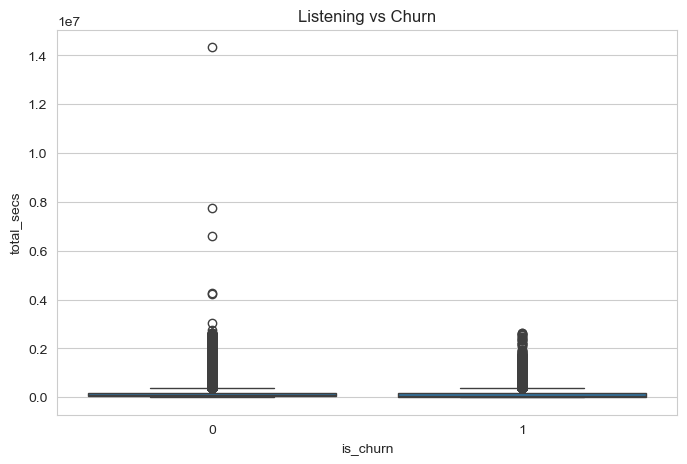

,total_secs,num_unq
is_churn,,
0,141113.079095,515.732526
1,126291.230177,472.744190


In [12]:
# 6.2 Behavioral patterns
sns.boxplot(data=df, x="is_churn", y="total_secs")
plt.title("Listening vs Churn")
plt.show()
df.groupby("is_churn")[["total_secs", "num_unq"]].mean()

 **Insight**
- Lower engagement is associated with higher churn
- Churned users listen less and explore less content

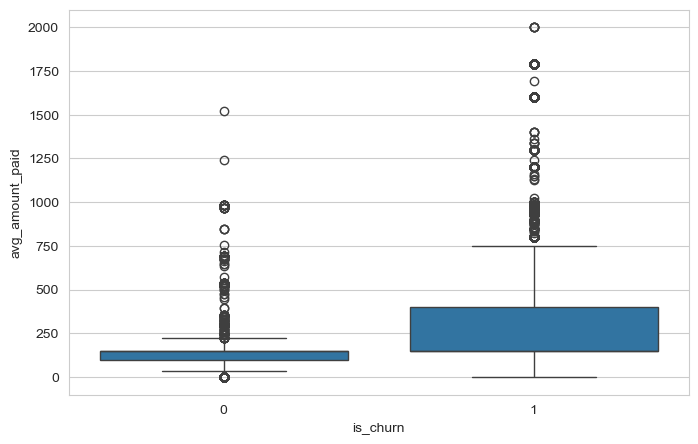

is_churn
0    129.000511
1    367.029821
Name: avg_amount_paid, dtype: float64

In [13]:
# 6.3 Payment behavior
sns.boxplot(data=df, x="is_churn", y="avg_amount_paid")
plt.show()

df.groupby("is_churn")["avg_amount_paid"].mean()


 **Insight**
- Payment-related variables show strong differences
- Suggests churn may be linked to plan type or pricing


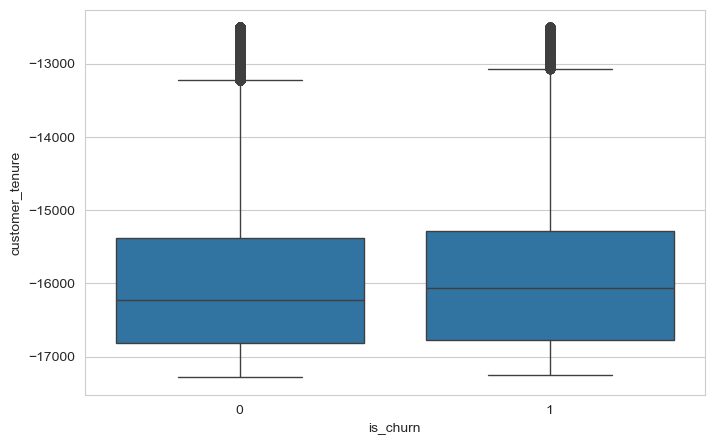

In [14]:
# 6.4 Timing of churn
df["registration_init_time"] = pd.to_datetime(
    df["registration_init_time"].astype("Int64").astype(str),
    format="%Y%m%d",
    errors="coerce"
)

df["customer_tenure"] = (
    df["last_transaction_date"] - df["registration_init_time"]
).dt.days
sns.boxplot(data=df, x="is_churn", y="customer_tenure")
plt.show()



**Insight**
- Churn appears related to lifecycle stage
- Early-stage users may behave differently from long-term users


In [15]:
# 6.5 Early risk signals
df["listening_group"] = pd.qcut(
    df["total_secs"], q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

df.groupby("listening_group")[target].mean() * 100


C:\Users\pauli\AppData\Local\Temp\ipykernel_22160\1134604873.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("listening_group")[target].mean() * 100


listening_group
Low            10.986652
Medium-Low      8.620214
Medium-High     8.102864
High            8.147351
Name: is_churn, dtype: float64

**Insight**
- Low engagement group shows highest churn
- Could be used for early intervention strategies


In [16]:
# 6.6 Risk segmentation

risk_table = df.groupby(
["has_auto_renew", "has_cancelled"]
)[target].agg(["mean", "count"]).reset_index()
risk_table["mean"] = risk_table["mean"] * 100
risk_table.columns = ["auto_renew", "cancelled", "churn_rate", "customers"]
risk_table = risk_table.sort_values("churn_rate", ascending=False).reset_index(drop=True)
risk_labels = ["High", "Medium", "Low"]
risk_table["risk_level"] = risk_labels[:len(risk_table)]
risk_table = risk_table[["risk_level", "auto_renew", "cancelled", "churn_rate", "customers"]]
risk_table["churn_rate"] = risk_table["churn_rate"].round(2)
print(risk_table)


  risk_level  auto_renew  cancelled  churn_rate  customers
0       High         1.0        1.0       60.26      32325
1     Medium         0.0        0.0       30.26      80777
2        Low         1.0        0.0        1.70     820476


**Insight**
- Highest risk group: customers who have cancelled their subscription, regardless of auto-renew status (60.26%)

- Medium risk: customers without auto-renew and no cancellation, indicating low commitment (30.26%)

- Lowest risk: customers with auto-renew and no cancellation, showing strong retention (1.70%)

- Key insight: cancellation behavior is the strongest predictor of churn, outweighing the effect of auto-renew.


In [17]:
# 7. ARPU only for churned customers
churned_customers = df["is_churn"].sum()
arpu_churn = df[df["is_churn"] == 1]["avg_amount_paid"].mean()
revenue_lost = churned_customers * arpu_churn

print(f"ARPU (churned users): €{arpu_churn:.2f}")
print(f"Estimated revenue lost: €{int(revenue_lost):,}")



ARPU (churned users): €367.03
Estimated revenue lost: €32,052,714


**Insight**
- ARPU (churned users): €367.03
- Estimated revenue lost: €32,052,714

In [21]:
# 8. ARPU only for no churned customers
arpu_non_churn = df[(df["is_churn"] == 0) & (df["avg_amount_paid"] > 0)]["avg_amount_paid"].median()

print(f"ARPU (non-churn users): €{arpu_non_churn:.2f}")


ARPU (non-churn users): €149.00


**Insight**
- ARPU (non-churn users): €149.00

In [22]:
# 9. Revenue opportunity estimation (simple proxy)
medium_risk_customers = 80777
potential_saved = medium_risk_customers * 0.10 # reduce churn by 10%

print(f"Potential customers saved whitin the medium-risk segment: {int(potential_saved)}")

Potential customers saved whitin the medium-risk segment: 8077


**Insight**
- Potential customers saved whitin the medium-risk segment: 8077 customers

In [25]:
# 10. Estimate revenue impact using real ARPU
revenue_saved = potential_saved * arpu_non_churn

print(f"Potential revenue saved: €{int(revenue_saved):,}")


Potential revenue saved: €1,203,577


**Insight**
- Potential revenue saved within the medium-risk churn segment: €1,203,577

---

####################################################################################################################################################

---

## **7. Conclusion**

The exploratory analysis indicates that churn in our platform is primarily associated with **behavioral factors** rather than demographic characteristics.

### Key Signals Identified

- **Subscription behavior**, especially cancellation and auto-renewal status  
- **Payment-related patterns**, such as plan duration and average amount paid  
- **User engagement**, particularly listening activity and content exploration  

These findings suggest that churn should be understood as a **behavioral process**, where declining engagement and cancellation intent play a central role.

---

### Data Perspective

Several important considerations were identified:

- The dataset is generally clean in key tables (e.g., `train`), with no missing values or duplicated user IDs  
- However, some variables require careful treatment:
  - `bd` (age) contains unrealistic values (zeros, negatives, extreme values)  
  - `gender` has a high proportion of missing values (~65%)  
- Some numerical variables behave as categorical (e.g., `city`, `registered_via`) and should be handled accordingly in future modeling  
- Data is distributed across multiple tables with different granularities (user-level vs. transaction-level vs. activity logs), requiring aggregation and careful feature engineering  

---

### Business Perspective

Churn is not only a customer retention issue but also a **significant revenue risk**:

- Churned users show higher ARPU (€367.03) compared to retained users (€149.00), indicating a disproportionate loss of higher-value customers  
- Under a simplified retention scenario, retaining 10% of customers in the medium-risk segment could recover approximately €1.2 million in revenue  

---

### Recommended Actions

- Incentives to encourage auto-renew activation  
- Re-engagement campaigns for low-activity users  
- Monitoring cancellation behavior as an early intervention trigger  

---

### Next Step

These insights provide a strong foundation for the next phase of the project, where **feature engineering and predictive modeling** will focus on capturing these behavioral patterns while addressing the identified data limitations.